In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import os

In [16]:
train_dir = 'Dataset/train'
val_dir = 'Dataset/val'
test_dir = 'Dataset/test'
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      
    width_shift_range=0.1,  
    height_shift_range=0.1, 
    shear_range=0.1,        
    zoom_range=0.2,         
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(244,244),
    batch_size=32,
    class_mode='binary'
)

val_data = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(244,244),
    batch_size=32,
    class_mode='binary'
)

test_data = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(244,244),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [17]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(244, 244, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
Flatten(),
    Dense(64, activation='relu'), 
    Dropout(0.5), 
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 242, 242, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 242, 242, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 121, 121, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 119, 119, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 119, 119, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 57, 57, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,801 (24.86 MB)

 Trainable params: 6,516,353 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history = model.fit(
    train_data,
    epochs=50, 
    validation_data=val_data,
    callbacks=[early_stopping]
)

Epoch 1/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8606 - loss: 0.3527 - val_accuracy: 0.5000 - val_loss: 8.3754
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9051 - loss: 0.2459 - val_accuracy: 0.5000 - val_loss: 8.9852
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9122 - loss: 0.2279 - val_accuracy: 0.5000 - val_loss: 4.3428
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9181 - loss: 0.2155 - val_accuracy: 0.6250 - val_loss: 0.7744
Epoch 5/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9218 - loss: 0.1984 - val_accuracy: 0.8125 - val_loss: 0.4153
Epoch 6/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9270 - loss: 0.2078 - val_accuracy: 0.8125 - val_loss: 0.4582
Epoch 7/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.9287 - loss: 0.1871 - val_accuracy: 0.8750 - val_loss: 0.3498
Epoch 8/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9294 - loss: 0.1897 - val_accu

In [19]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 565ms/step - accuracy: 0.8606 - loss: 0.3070
Test Accuracy: 86.06%


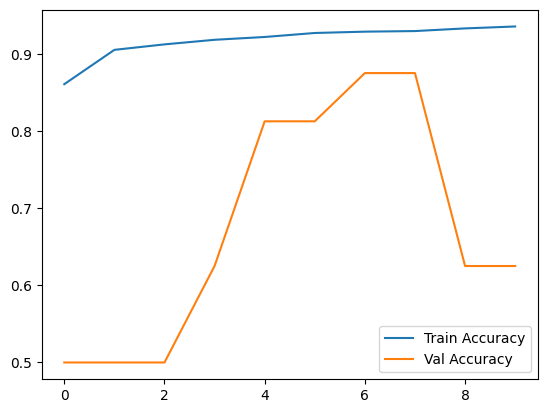

In [20]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 562ms/step


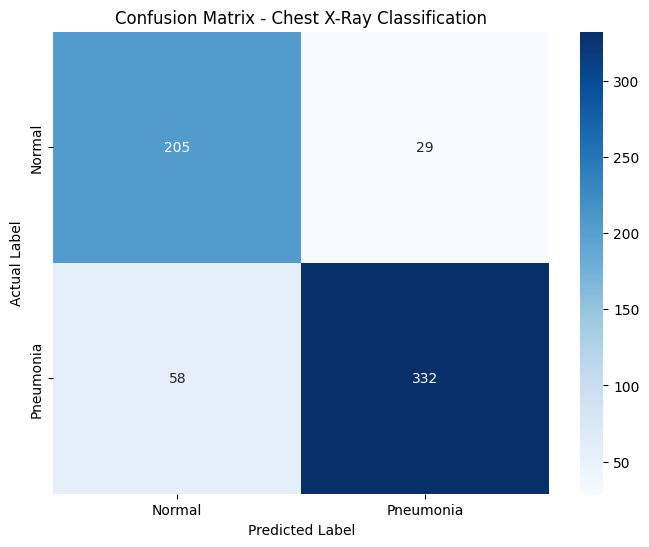


Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.88      0.82       234
   Pneumonia       0.92      0.85      0.88       390

    accuracy                           0.86       624
   macro avg       0.85      0.86      0.85       624
weighted avg       0.87      0.86      0.86       624



In [21]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

true_labels = test_data.classes

predictions = model.predict(test_data, steps=len(test_data))
predicted_labels = np.where(predictions > 0.5, 1, 0)

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])

plt.title('Confusion Matrix - Chest X-Ray Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=['Normal', 'Pneumonia']))